In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler,normalize
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc

In [3]:
#loading the data
x = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\clustering\CC GENERAL (1).csv")

# dropping cust_id column, which is used for indentification. no need in case of clustering
x = x.drop("CUST_ID",axis = 1)

#handle missing values
x.fillna(method = 'ffill',inplace = True)


C:\Users\DELL\AppData\Local\Temp\ipykernel_19560\1203881794.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x.fillna(method = 'ffill',inplace = True)


In [4]:
x.shape

(8950, 17)

In [5]:
x.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [6]:
x.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [7]:
#scaling data so that  all features become comparable
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)

x_normalized = normalize(x_scaled)

#converting from numpy array into panda dataframe
x_normalized = pd.DataFrame(x_normalized)


In [8]:
x_normalized.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,-0.312038,-0.106331,-0.181129,-0.152156,-0.148808,-0.198985,-0.343796,-0.289304,-0.301518,-0.287892,-0.202942,-0.217975,-0.409413,-0.225497,-0.130160,-0.224036,0.153753
1,0.219928,0.037539,-0.131224,-0.099751,-0.127038,0.728177,-0.341439,-0.189662,-0.256269,0.160403,0.030762,-0.165387,0.192455,0.228782,0.024353,0.065458,0.100798
2,0.126684,0.146785,-0.030505,0.030851,-0.128792,-0.132251,0.359775,0.757449,-0.259805,-0.191342,-0.134881,-0.030888,0.234046,-0.108741,-0.028363,-0.148900,0.102189
3,0.020571,-0.426063,0.097223,0.228832,-0.190449,-0.154451,-0.424878,-0.167299,-0.384185,-0.108474,-0.138062,-0.231084,0.346093,-0.250827,-0.041942,-0.220185,0.151110
4,-0.151630,0.218959,-0.195282,-0.146778,-0.192118,-0.197278,-0.428601,-0.168765,-0.387551,-0.285424,-0.201202,-0.233109,-0.382671,-0.153993,-0.110323,-0.222114,0.152435


In [9]:
x_normalized.shape

(8950, 17)

In [10]:
pca = PCA(n_components = 2) # n_components = 2 means , converting data into 2 dimensions

x_principal = pca.fit_transform(x_normalized)

#converting from numpy array into pandas dataframe
x_principal = pd.DataFrame(x_principal)
x_principal.columns = ['p1','p2']


In [11]:
x_principal.shape

(8950, 2)

In [12]:
x_principal.head()

,p1,p2
0,-0.489949,-0.679976
1,-0.519099,0.544827
2,0.330633,0.268879
3,-0.481656,-0.097611
4,-0.563512,-0.482506


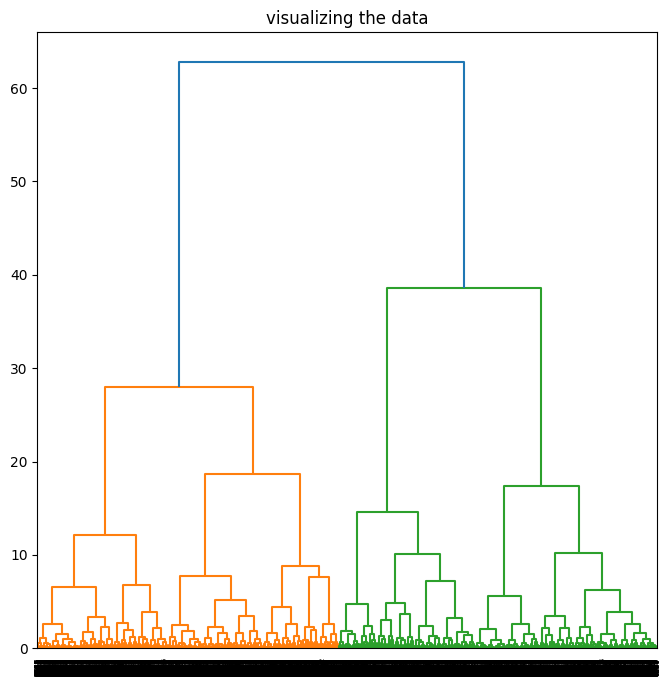

In [13]:
plt.figure(figsize=(8,8))
plt.title("visualizing the data")

#we have 8950 rows, to draw a dendogram , consider all rows such as first take each row as a leaf node and then it starts merging.so, it takes too much time to process..
dendogram = shc.dendrogram((shc.linkage(x_principal,method = 'ward')))

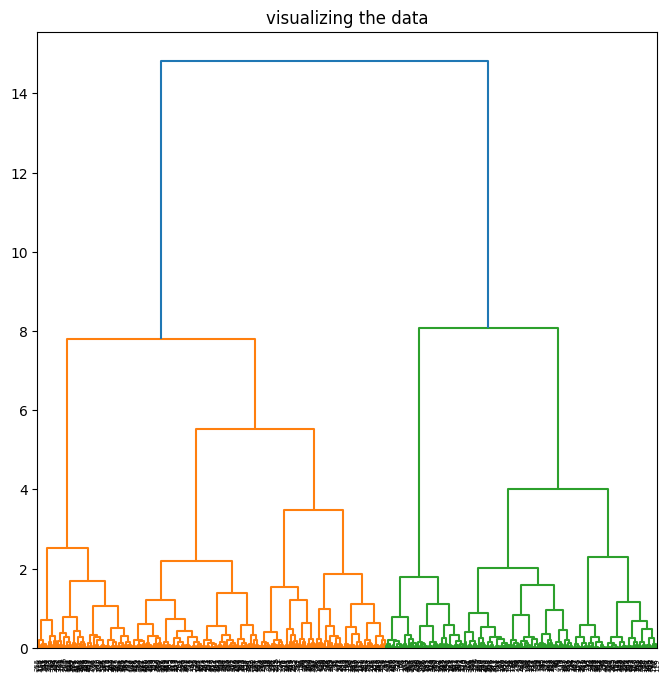

In [14]:
#reeducing row count . so , we get the required dendogram earlier than whole datset(8950 rows)...
sample = x_principal[:500]


plt.figure(figsize=(8,8))
plt.title("visualizing the data")

dendogram = shc.dendrogram((shc.linkage(sample,method = 'ward')))

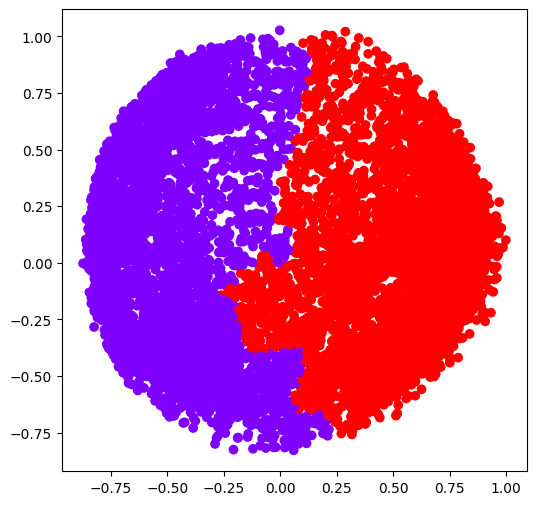

In [15]:
ac2 = AgglomerativeClustering(n_clusters = 2)

plt.figure(figsize=(6,6))
plt.scatter(x_principal['p1'],x_principal['p2'],c = ac2.fit_predict(x_principal),cmap = 'rainbow')
plt.show()

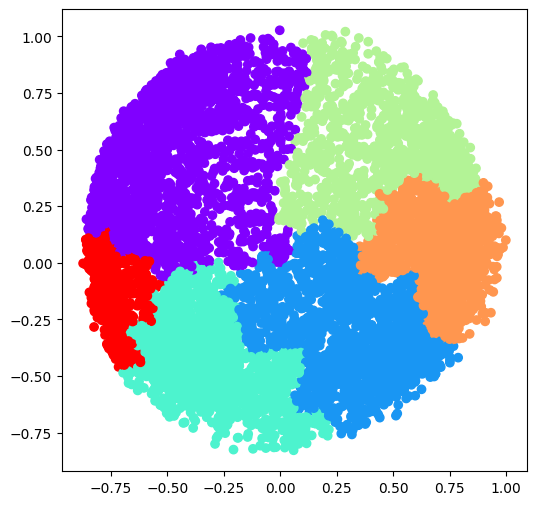

In [23]:
ac3 = AgglomerativeClustering(n_clusters = 3)

plt.figure(figsize=(6,6))
plt.scatter(x_principal['p1'],x_principal['p2'],c = ac2.fit_predict(x_principal),cmap = 'rainbow')
plt.show()

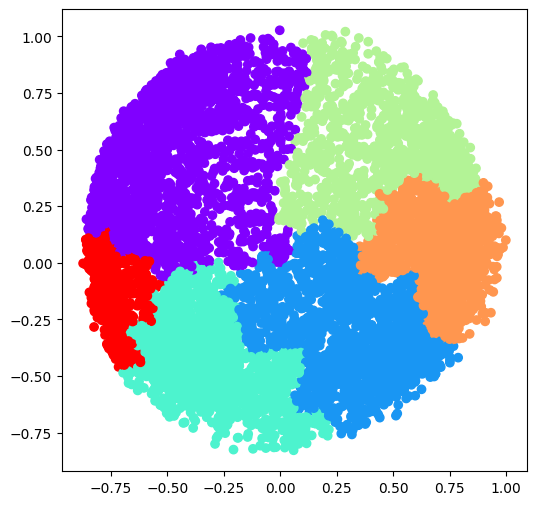

In [24]:
ac4 = AgglomerativeClustering(n_clusters = 4)

plt.figure(figsize=(6,6))
plt.scatter(x_principal['p1'],x_principal['p2'],c = ac2.fit_predict(x_principal),cmap = 'rainbow')
plt.show()

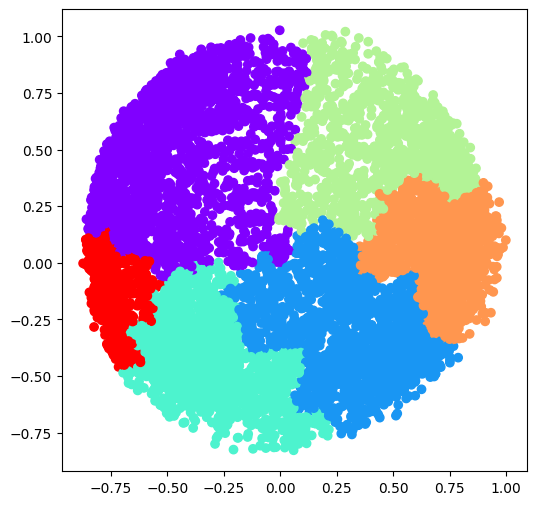

In [25]:
ac5 = AgglomerativeClustering(n_clusters = 5)

plt.figure(figsize=(6,6))
plt.scatter(x_principal['p1'],x_principal['p2'],c = ac2.fit_predict(x_principal),cmap = 'rainbow')
plt.show()

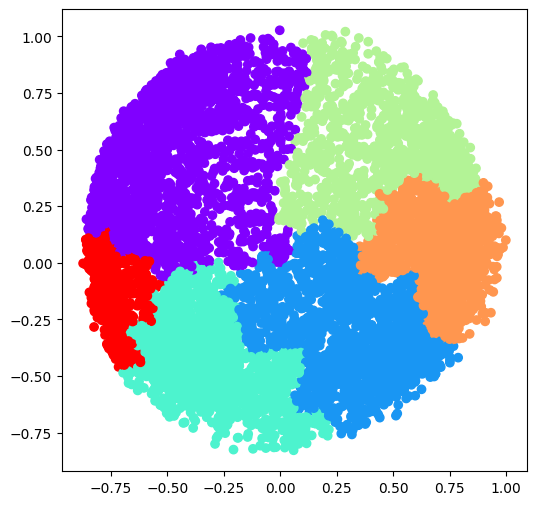

In [26]:
ac6 = AgglomerativeClustering(n_clusters = 6)

plt.figure(figsize=(6,6))
plt.scatter(x_principal['p1'],x_principal['p2'],c = ac2.fit_predict(x_principal),cmap = 'rainbow')
plt.show()

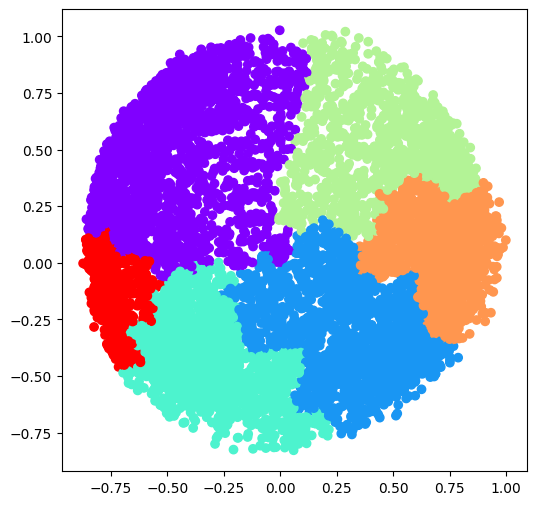

In [27]:
ac7 = AgglomerativeClustering(n_clusters = 7)

plt.figure(figsize=(6,6))
plt.scatter(x_principal['p1'],x_principal['p2'],c = ac2.fit_predict(x_principal),cmap = 'rainbow')
plt.show()

In [28]:
# Evaluating the different models and Visualizing the results.

K = [2, 3, 4, 5, 6,7]
  
# Appending the silhouette scores of the different models to the list
silhouette_scores = []
silhouette_scores.append(
        silhouette_score(x_principal, ac2.fit_predict(x_principal)))
silhouette_scores.append(
        silhouette_score(x_principal, ac3.fit_predict(x_principal)))
silhouette_scores.append(
        silhouette_score(x_principal, ac4.fit_predict(x_principal)))
silhouette_scores.append(
        silhouette_score(x_principal, ac5.fit_predict(x_principal)))
silhouette_scores.append(
        silhouette_score(x_principal, ac6.fit_predict(x_principal)))
silhouette_scores.append(
        silhouette_score(x_principal, ac7.fit_predict(x_principal)))

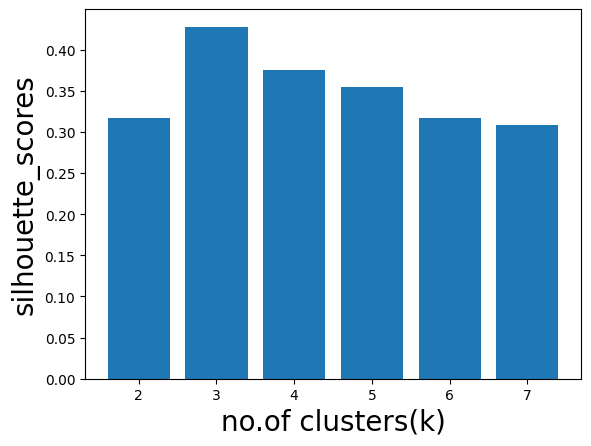

In [30]:
plt.bar(K,silhouette_scores)
plt.xlabel("no.of clusters(k)",fontsize = 20)
plt.ylabel("silhouette_scores",fontsize = 20)
plt.show()